In [86]:
import msprime
from matplotlib import pyplot as plt
import numpy as np
import concurrent.futures as cf


In [96]:
pop_size = 1000
n = 5
loci=10000

<BarContainer object of 4 artists>

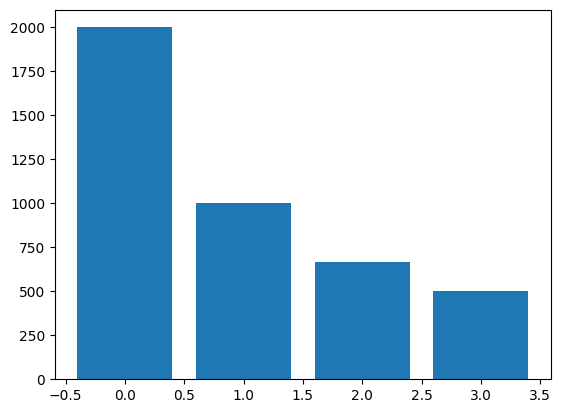

In [97]:
theoritical_sfs = [2*pop_size/(i+1) for i in range(n-1)]
plt.bar(range(len(theoritical_sfs)), theoritical_sfs)


In [98]:
def error(sfs, base=None):
    if base is None: base = theoritical_sfs
    assert len(sfs) == len(base)
    return np.sqrt(np.mean([(sfs[i]-base[i])**2 for i in range(len(sfs))]))

errors = []
for l in range(loci):
    l+=1
    sfss = [0]*(n-1)
    replicates = msprime.sim_ancestry(
        samples=n,
        sequence_length=1,
        recombination_rate=0,
        num_replicates=l,
        ploidy=1,
        population_size=pop_size,
        model=msprime.SmcKApproxCoalescent(hull_offset=1)
    )

    for rep in replicates:
        sfss += (rep.allele_frequency_spectrum(polarised=True, span_normalise=True, mode='branch')[1:-1])
    sfs = sfss/l
    errors.append(error(sfs))



In [99]:
errors = []

def simulate_locus(l):
    """Simulate one locus and return its error."""
    sfss = [0] * (n - 1)
    replicates = msprime.sim_ancestry(
        samples=n,
        sequence_length=1,
        recombination_rate=0,
        num_replicates=l + 1,  # because your loop did l += 1
        ploidy=1,
        population_size=pop_size,
        model=msprime.SmcKApproxCoalescent(hull_offset=1)
    )

    for rep in replicates:
        sfss += rep.allele_frequency_spectrum(
            polarised=True,
            span_normalise=True,
            mode="branch"
        )[1:-1]
    sfs = sfss / (l + 1)
    return error(sfs)


def parallel_simulation(loci, max_workers=4):
    with cf.ProcessPoolExecutor(max_workers=max_workers) as executor:
        errors = list(executor.map(simulate_locus, range(loci)))
    return errors

errors = parallel_simulation(loci, max_workers=16)

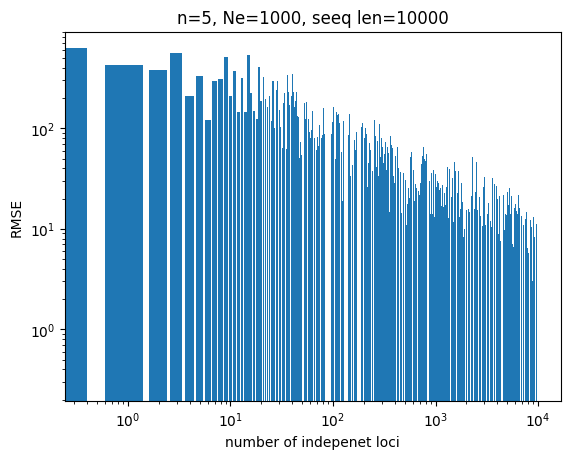

In [105]:
plt.bar(range(len(errors)), errors)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('number of indepenet loci')
plt.ylabel('RMSE')
plt.title(f'n={n}, Ne={pop_size}, seeq len={loci}')
plt.show()

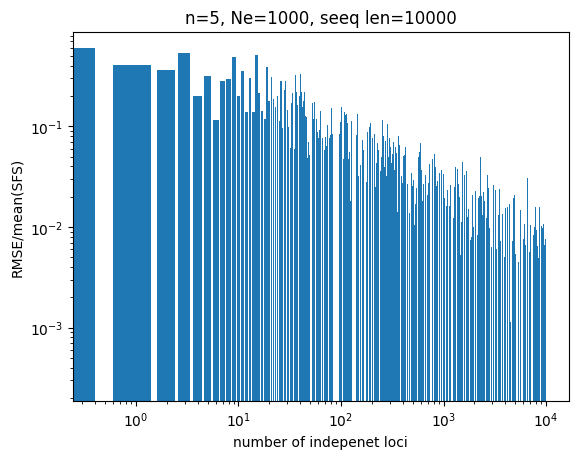

In [106]:
scaled_error = [e/np.mean(theoritical_sfs) for e in errors]
plt.bar(range(len(scaled_error)), scaled_error)
plt.yscale('log')
plt.xscale('log')

plt.xlabel('number of indepenet loci')
plt.ylabel('RMSE/mean(SFS)')
plt.title(f'n={n}, Ne={pop_size}, seeq len={loci}')
plt.show()

# Varying r

In [102]:
pop_size = 1000
r_range = np.logspace(-5, -1, 10)
r_range = np.concatenate([r_range, [0,1]])
r_range = np.sort(r_range)

In [103]:
r_errors = []
for r in r_range:
    sfss = [0]*(n-1)
    ts = msprime.sim_ancestry(
        samples=n,
        sequence_length=loci,
        recombination_rate=r,
        ploidy=1,
        population_size=pop_size,
        model=msprime.SmcKApproxCoalescent(hull_offset=1)

    )

    sfs = ts.allele_frequency_spectrum(polarised=True, span_normalise=True, mode='branch')[1:-1]
    r_errors.append(error(sfs))



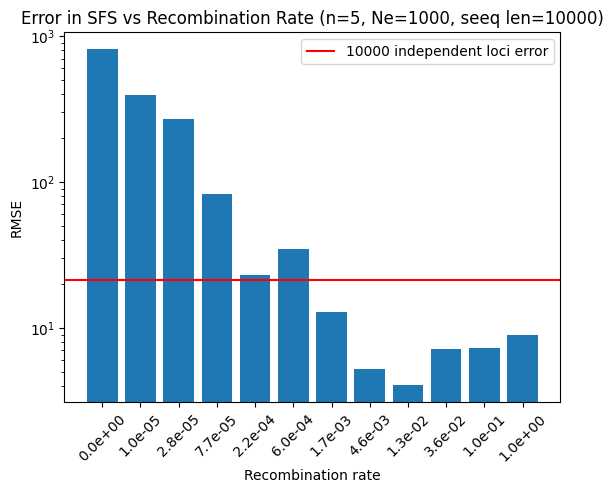

In [104]:
plt.bar(range(len(r_errors)), r_errors)
plt.yscale('log')
plt.xticks(range(len(r_errors)), [f"{r:.1e}" for r in r_range], rotation=45)
plt.axhline(y=errors[-1], color='r', linestyle='-', label=f'{loci} independent loci error')

plt.xlabel('Recombination rate')
plt.ylabel('RMSE')
plt.title(f'Error in SFS vs Recombination Rate (n={n}, Ne={pop_size}, seeq len={loci})')
plt.legend()
plt.show()